## VLMs Inference on BNP Paribas File

In [1]:
!pip install pymupdf pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 109.3 MB/s eta 0:00:00


In [2]:
import os
import shutil
import zipfile
import re
import ast
import fitz
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from peft import PeftModel

## Add the two ZIP files containing the weights trained and the BNP File

In [3]:
# ============================================================
# 1) Paths
# ============================================================
SIG_ZIP = "/content/internvl_vision_LORA_signature_ft.zip"
STAMP_ZIP = "/content/internvl_vision_LORA_stamp_ft.zip"

SIG_DIR = "/content/internvl_vision_LORA_signature_ft"
STAMP_DIR = "/content/internvl_vision_LORA_stamp_ft"

MODEL_ID = "OpenGVLab/InternVL3_5-4B-HF"

PDF_PATH = "/content/Annual report sample.pdf"
PAGE_NUM = 1
ZOOM = 2.0

In [4]:
# ============================================================
# 2) Unzip both adapters
# ============================================================
for out_dir in [SIG_DIR, STAMP_DIR]:
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

with zipfile.ZipFile(SIG_ZIP, "r") as z:
    z.extractall(SIG_DIR)

with zipfile.ZipFile(STAMP_ZIP, "r") as z:
    z.extractall(STAMP_DIR)

def find_adapter_dir(root_dir):
    candidate = os.path.join(root_dir, "final")
    if os.path.isdir(candidate):
        return candidate
    return root_dir

SIG_ADAPTER_DIR = find_adapter_dir(SIG_DIR)
STAMP_ADAPTER_DIR = find_adapter_dir(STAMP_DIR)

print("SIG_ADAPTER_DIR:", SIG_ADAPTER_DIR)
print("STAMP_ADAPTER_DIR:", STAMP_ADAPTER_DIR)
# ============================================================
# 3) Device / dtype / processor
# ============================================================
use_cuda = torch.cuda.is_available()

if use_cuda:
    cap_major, cap_minor = torch.cuda.get_device_capability(0)
    dtype = torch.bfloat16 if cap_major >= 8 else torch.float16
else:
    dtype = torch.float32

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True
)

# ============================================================
# 4) Base loader + two models
# ============================================================
def load_base_model():
    base_model = AutoModelForImageTextToText.from_pretrained(
        MODEL_ID,
        trust_remote_code=True,
        torch_dtype=dtype,
        low_cpu_mem_usage=True,
    )
    base_model = base_model.cuda() if use_cuda else base_model.cpu()
    base_model.eval()
    return base_model

base_model_1 = load_base_model()
model_1 = PeftModel.from_pretrained(
    base_model_1,
    SIG_ADAPTER_DIR,
    is_trainable=False
)
model_1.eval()

base_model_2 = load_base_model()
model_2 = PeftModel.from_pretrained(
    base_model_2,
    STAMP_ADAPTER_DIR,
    is_trainable=False
)
model_2.eval()

print("model_1 ready: signature model")
print("model_2 ready: stamp model")

SIG_ADAPTER_DIR: /content/internvl_vision_LORA_signature_ft/final
STAMP_ADAPTER_DIR: /content/internvl_vision_LORA_stamp_ft/final


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/481 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/841 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/841 [00:00<?, ?it/s]

model_1 ready: signature model
model_2 ready: stamp model


In [5]:
# ============================================================
# 5) Same strategy as your current code
# ============================================================
def move_inputs_to_device(inputs, model, use_cuda):
    target_device = model.device if use_cuda else torch.device("cpu")
    out = {}
    for k, v in inputs.items():
        if torch.is_tensor(v):
            out[k] = v.to(target_device)
        else:
            out[k] = v
    return out


def predict_on_image(model, image, user_text, max_new_tokens=256):
    prompt = f"<IMG_CONTEXT>\n{user_text}"

    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    )

    target_device = model.device if torch.cuda.is_available() else torch.device("cpu")
    inputs = {
        k: v.to(target_device) if torch.is_tensor(v) else v
        for k, v in inputs.items()
    }

    input_len = inputs["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            temperature=None,
            top_p=None,
            repetition_penalty=1.1,
            eos_token_id=processor.tokenizer.eos_token_id,
            pad_token_id=processor.tokenizer.eos_token_id,
        )

    new_tokens = output_ids[:, input_len:]
    pred = processor.batch_decode(new_tokens, skip_special_tokens=True)[0].strip()
    return pred

In [6]:
# ============================================================
# 6) Prompts
# ============================================================
USER_TEXT_1 = """Detect all signatures.
Return only JSON.
Format:
[
  {"label":"signature","bbox":[x1,y1,x2,y2],"text":"..."},
]
If none, return [].
Do not explain."""

USER_TEXT_2 = """Detect all stamps when available.
Return only JSON.
Format:
[
  {"label":"stamp","bbox":[x1,y1,x2,y2],"text":"..."},
]
If none, return [].
Do not explain."""

# ============================================================
# 7) PDF utilities
# ============================================================
def pdf_page_to_pil(pdf_path, page_idx=0, zoom=2.0):
    doc = fitz.open(pdf_path)
    page = doc[page_idx]
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()
    return img

import re
import ast

def parse_pred_boxes(text):
    text = text.strip()
    out = []

    # Try to isolate the JSON-like list
    start = text.find("[")
    end = text.rfind("]")
    if start != -1 and end != -1 and end > start:
        candidate = text[start:end + 1]
    else:
        candidate = text

    # --------------------------------------------------------
    # 1) Try normal literal parsing
    # --------------------------------------------------------
    try:
        data = ast.literal_eval(candidate)
        if isinstance(data, list):
            for obj in data:
                if isinstance(obj, dict) and "bbox" in obj and "label" in obj:
                    bbox = obj["bbox"]
                    label = str(obj["label"])
                    if isinstance(bbox, (list, tuple)):
                        nums = []
                        for x in bbox:
                            try:
                                nums.append(float(x))
                            except Exception:
                                break
                        if len(nums) >= 4:
                            out.append((label, nums[:4]))
            if out:
                return out
    except Exception:
        pass

    # --------------------------------------------------------
    # 2) Regex fallback:
    #    capture bbox contents even if extra text is inside
    # --------------------------------------------------------
    pattern = re.compile(
        r'"label"\s*:\s*"([^"]+)"\s*,\s*"bbox"\s*:\s*\[([^\]]+)\]',
        re.IGNORECASE | re.DOTALL
    )

    for label, bbox_str in pattern.findall(text):
        nums = re.findall(r'-?\d+(?:\.\d+)?', bbox_str)
        if len(nums) >= 4:
            bbox = list(map(float, nums[:4]))
            out.append((label, bbox))

    return out

def maybe_denorm_bbox(bbox, W, H):
    x1, y1, x2, y2 = bbox

    if max(x1, y1, x2, y2) <= 1000:
        return [
            x1 / 1000.0 * W,
            y1 / 1000.0 * H,
            x2 / 1000.0 * W,
            y2 / 1000.0 * H,
        ]

    return [x1, y1, x2, y2]

In [7]:
# ============================================================
# 8) Run both models on multiple BNP pages
# ============================================================
PAGE_LIST = [1, 3, 99, 209, 211, 217, 54]

all_results = {}

for PAGE_NUM in PAGE_LIST:
    print("=" * 80)
    print(f"Processing PAGE {PAGE_NUM}")

    page_idx = PAGE_NUM - 1
    image = pdf_page_to_pil(PDF_PATH, page_idx=page_idx, zoom=ZOOM)

    pred_1 = predict_on_image(model_1, image, USER_TEXT_1, max_new_tokens=256)
    parsed_1 = parse_pred_boxes(pred_1)

    pred_2 = predict_on_image(model_2, image, USER_TEXT_2, max_new_tokens=256)
    parsed_2 = parse_pred_boxes(pred_2)

    all_results[PAGE_NUM] = {
        "image": image,
        "pred_1": pred_1,
        "parsed_1": parsed_1,
        "pred_2": pred_2,
        "parsed_2": parsed_2,
    }

    print(f"=== PAGE {PAGE_NUM} | SIGNATURE MODEL ===")
    print(pred_1)
    print("\nParsed boxes:", parsed_1)

    print(f"\n=== PAGE {PAGE_NUM} | STAMP MODEL ===")
    print(pred_2)
    print("\nParsed boxes:", parsed_2)
    print()

Processing PAGE 1
=== PAGE 1 | SIGNATURE MODEL ===
```json
[]```


```json
[
    {"label":"signature","bbox":[304,657,498,700,"Calva S A S"],
    {"label":"signature","bbox":[630,669,998,712,"Georgina Cromwell"]
}
]
```

Parsed boxes: [('signature', [304.0, 657.0, 498.0, 700.0]), ('signature', [630.0, 669.0, 998.0, 712.0])]

=== PAGE 1 | STAMP MODEL ===
Only show the:
- text on stamp
- coordinates of each stamp (x1, y1) top-left, (x2, y2) bottom-right

```json
[
  {"label":"stamp","bbox":[579,86,880,243],"text":"FS1"},
  {"label":"stamp","bbox":[35,555,235,757],"text":"CRO\nJUL 2025\nFEE PAID IN FULL\n28 JUL 2025"}
]
````
```json
[
  {"label":"stamp","bbox":[579,86,880,243],"text":"FS1"},
  {"label":"stamp","bbox":[35,555,235,757],"text":"CRO\nJUL 2025\nFEE PAID IN FULL\n28 JUL 2025"}
]
``````

Parsed boxes: [('stamp', [579.0, 86.0, 880.0, 243.0]), ('stamp', [35.0, 555.0, 235.0, 757.0]), ('stamp', [579.0, 86.0, 880.0, 243.0]), ('stamp', [35.0, 555.0, 235.0, 757.0])]

Processing PAGE 3


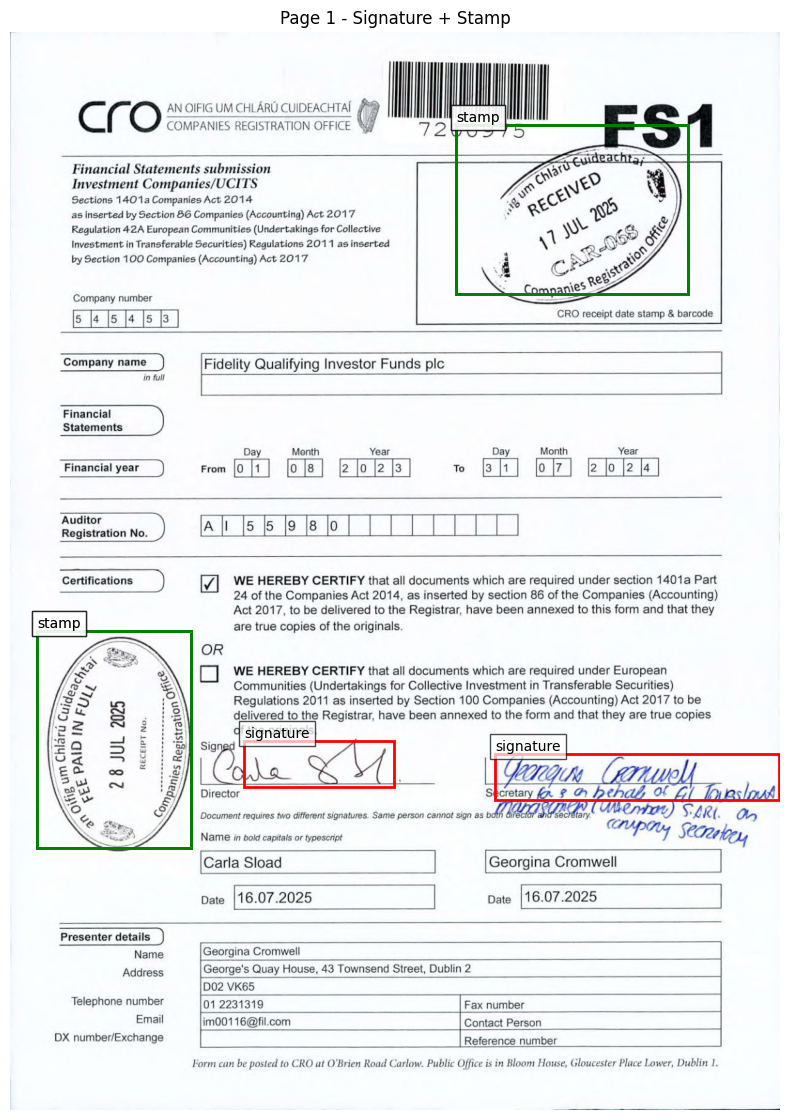

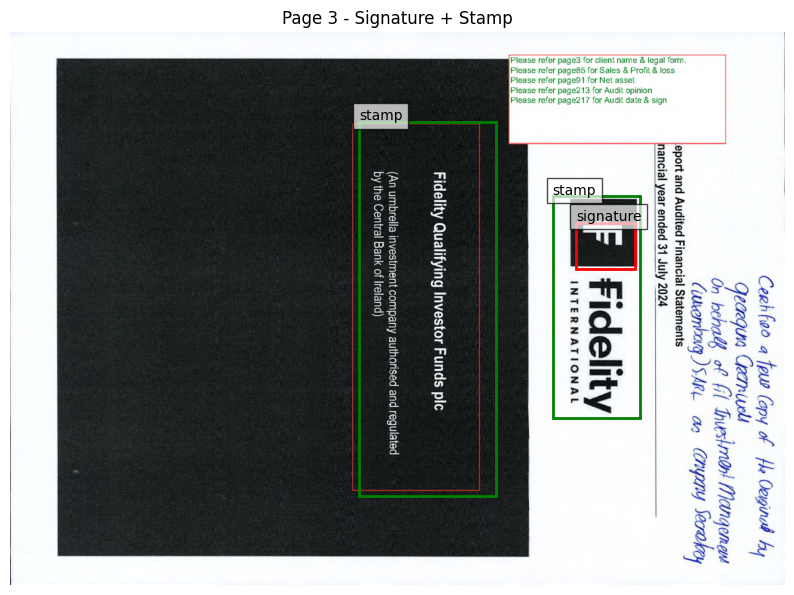

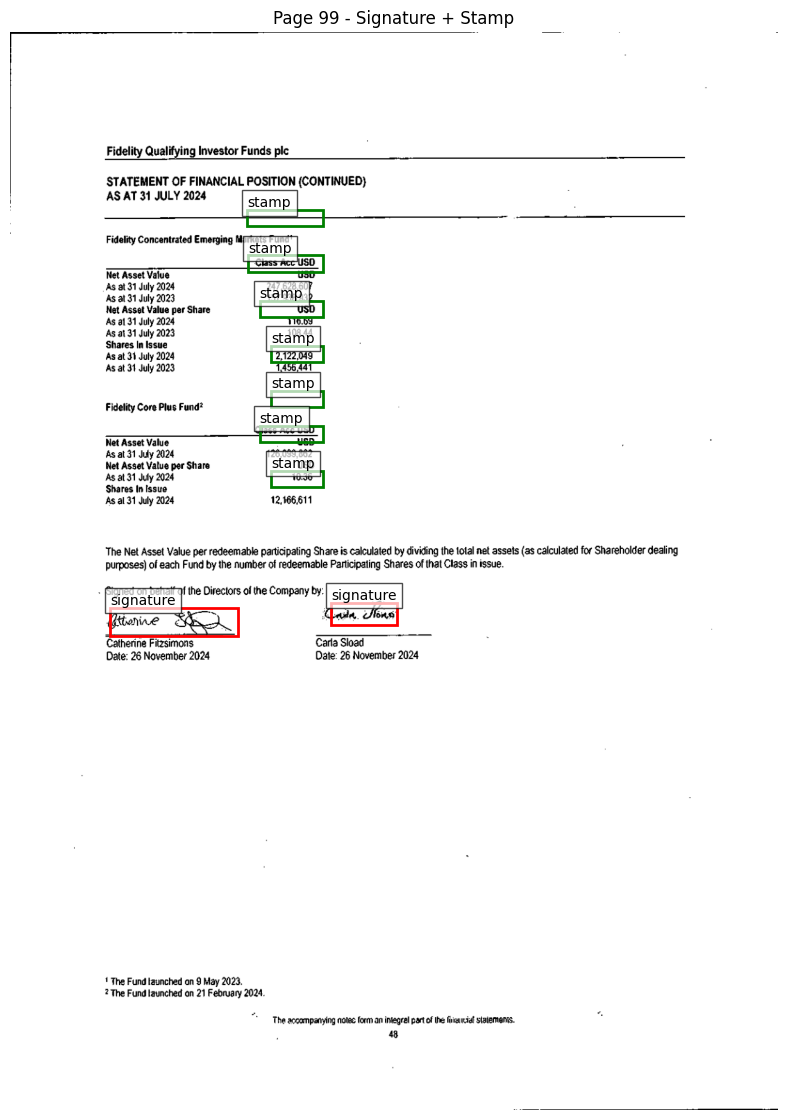

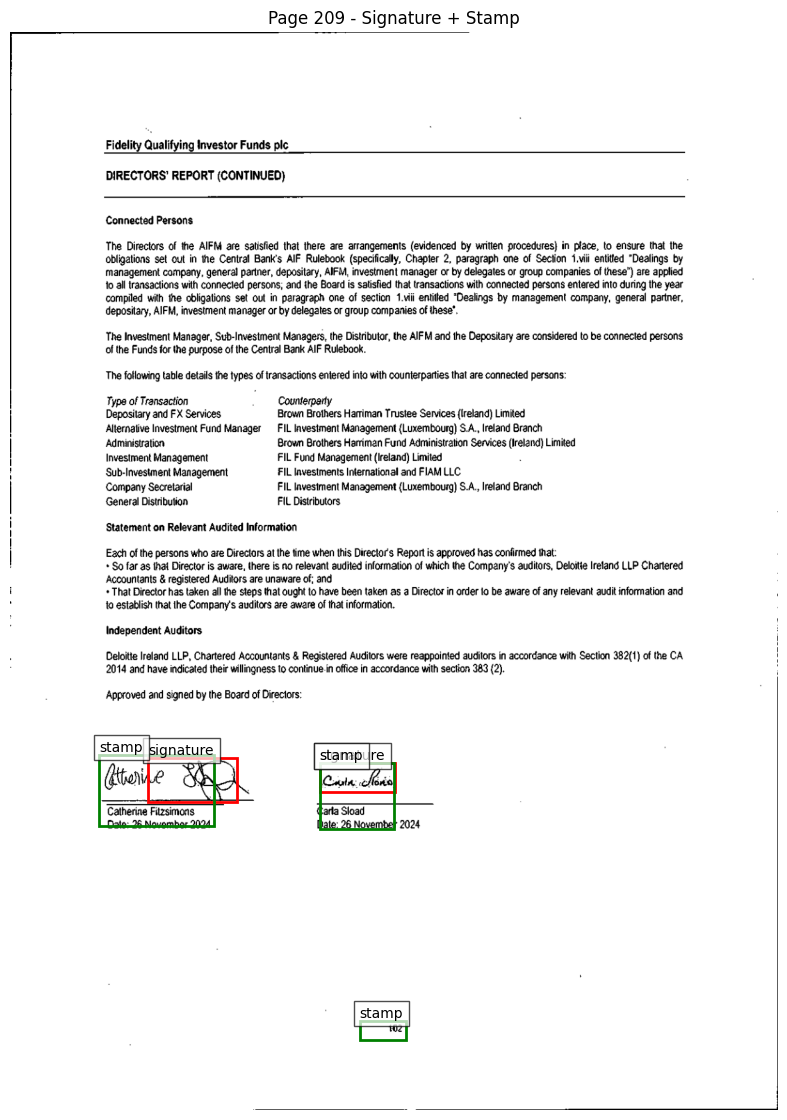

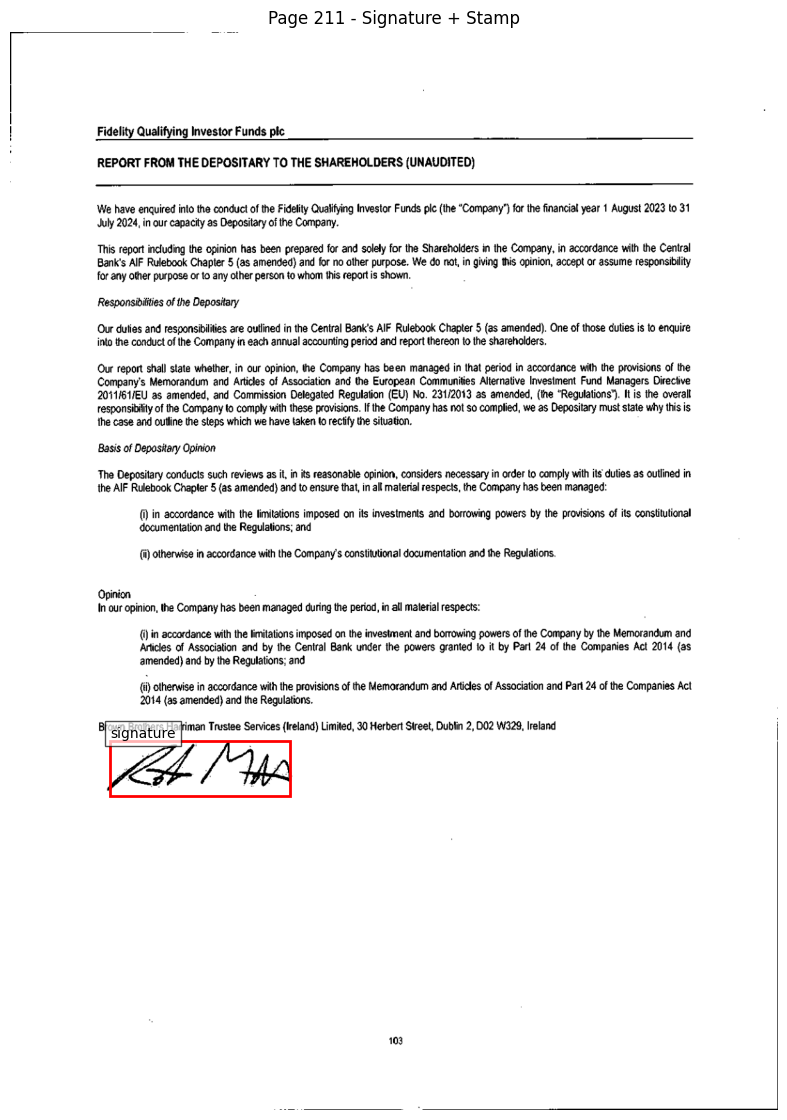

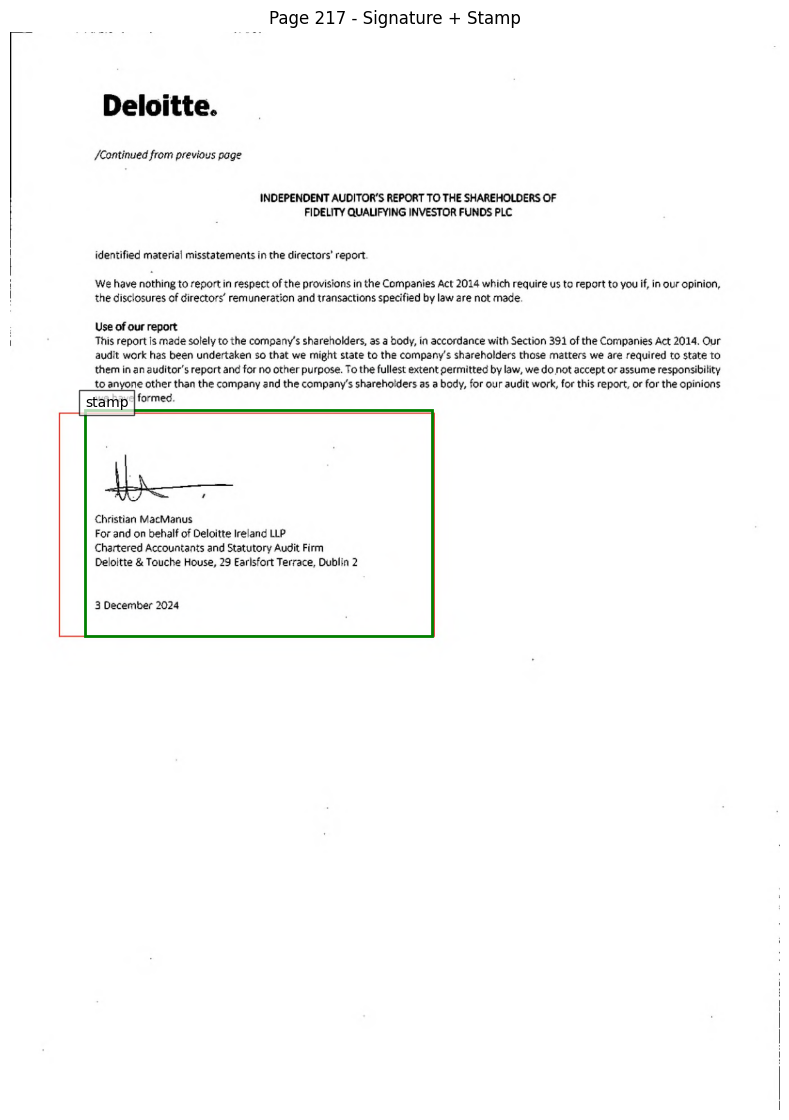

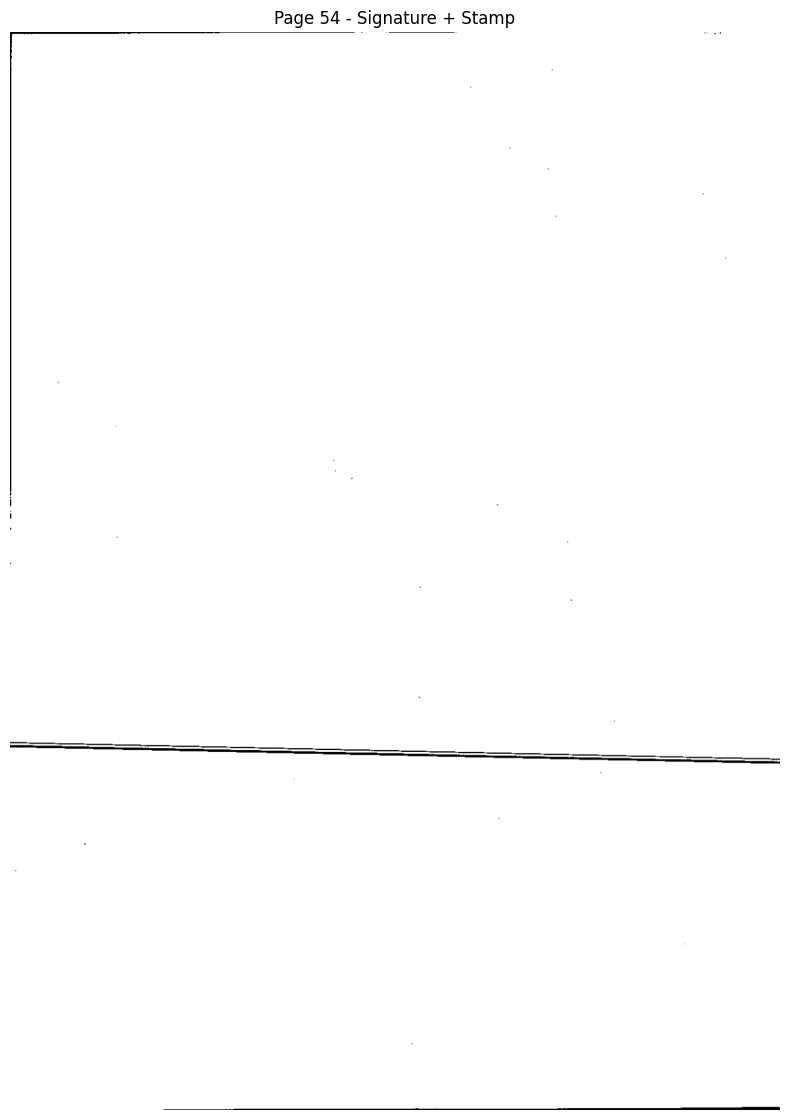

In [8]:
# ============================================================
# 11) Visualize both together for all selected pages
# ============================================================
for PAGE_NUM in PAGE_LIST:
    image = all_results[PAGE_NUM]["image"]
    parsed_1 = all_results[PAGE_NUM]["parsed_1"]
    parsed_2 = all_results[PAGE_NUM]["parsed_2"]

    W, H = image.size

    plt.figure(figsize=(10, 14))
    plt.imshow(image)
    ax = plt.gca()

    for label, bbox in parsed_1:
        x1, y1, x2, y2 = maybe_denorm_bbox(bbox, W, H)
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
            edgecolor="red"
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 5),
            "signature",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7)
        )

    for label, bbox in parsed_2:
        x1, y1, x2, y2 = maybe_denorm_bbox(bbox, W, H)
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
            edgecolor="green"
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(0, y1 - 5),
            "stamp",
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7)
        )

    plt.title(f"Page {PAGE_NUM} - Signature + Stamp")
    plt.axis("off")
    plt.show()